# <font color=green>LivingEarth PNG - FAO LCCS Level 3</font>

### An environmental layers testing framework for the FAO land cover classification system

The purpose of this notebook is to provide an easy-to-use method for testing environmental layers to use for classification and seeing how changes to particular layers effect the final Land Cover Classification. You can easily test with different environmental layer inputs, and different locations. 

This code defines 5 variables to contain the binary layers required to reach a level 3 classification:
1. <font color=blue>**vegetat_veg_cat:**</font> Vegetated / Non-Vegetated 
2. <font color=blue>**aquatic_wat_cat:**</font> Aquatic / Terrestrial 
3. <font color=blue>**cultman_agr_cat:**</font> Natural Vegetation / Crop or Managed Vegetation
4. <font color=blue>**artific_urb_cat:**</font> Natural Surfaces / Artificial Surfaces
5. <font color=blue>**artwatr_wat_cat:**</font> Natural Water / Artificial Water

Whilst this example is using open data cube to load the required data, it can be loaded from anywhere - so long as all input layers cover the same geographic region and are defined in a correctly labelled dataset, before being passed to the classification code.

#### Install the environment (need DEA fc and wofs packages) using the following on command line

In [1]:
'''
python3 -m venv ~/venvs/VP_Environment
source ~/venvs/VP_Environment/bin/activate
deactivate
realpath /env/lib/python3.10/site-packages > ~/venvs/VP_Environment/lib/python3.10/site-packages/base_venv.pth
source ~/venvs/VP_Environment/bin/activate
pip install --extra-index-url=https://packages.dea.ga.gov.au/ fc
pip install ephem
pip install --index-url https://packages.dea.ga.gov.au/ wofs
python -m ipykernel install --user --name=VP_Environment
cd venvs/VP_Environment
touch setup.py

##### add in text below to setup.py

from setuptools import setup, find_packages

setup(
    name='VP_Environment',
    version='1.0',
    packages=find_packages(),
    install_requires=[
        'ephem',
        'wofs',
        'fc'
    ],
)

#####

python setup.py bdist_egg

'''

"\npython3 -m venv ~/venvs/VP_Environment\nsource ~/venvs/VP_Environment/bin/activate\ndeactivate\nrealpath /env/lib/python3.10/site-packages > ~/venvs/VP_Environment/lib/python3.10/site-packages/base_venv.pth\nsource ~/venvs/VP_Environment/bin/activate\npip install --extra-index-url=https://packages.dea.ga.gov.au/ fc\npip install ephem\npip install --index-url https://packages.dea.ga.gov.au/ wofs\npython -m ipykernel install --user --name=VP_Environment\ncd venvs/VP_Environment\ntouch setup.py\n\n##### add in text below to setup.py\n\nfrom setuptools import setup, find_packages\n\nsetup(\n    name='VP_Environment',\n    version='1.0',\n    packages=find_packages(),\n    install_requires=[\n        'ephem',\n        'wofs',\n        'fc'\n    ],\n)\n\n#####\n\npython setup.py bdist_egg\n\n"

### **Import modules**

In [2]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import os, sys

import numpy as np
import xarray as xr
import geopandas as gpd
import rasterio
import rioxarray

from matplotlib import pyplot
import matplotlib.pyplot as plt

import datacube
from datacube.utils import masking
from datacube.utils.geometry import CRS
from dea_tools.plotting import display_map
from dea_tools.spatial import xr_rasterize
from datacube.testutils.io import rio_slurp_xarray

#import le_lccs modules
# sys.path.append("../livingearth_lccs")
from le_lccs.le_ingest import gridded_ingest
from le_lccs.le_classification import lccs_l3

# for virtual products
from pathlib import Path
repo = Path.home() / 'livingearth_png/le_plugins'
sys.path.insert(1, str(repo))
import yaml
import importlib
from datacube.virtual import catalog_from_file
from datacube.virtual import DEFAULT_RESOLVER

# outputs
from datacube.utils.cog import write_cog
from datacube.drivers.netcdf import write_dataset_to_netcdf

dc = datacube.Datacube(app="level3")

# virtual product catalog
catalog = catalog_from_file('../le_plugins/virtual_product_cat.yaml')


### NEW

# Import colour schems for display
sys.path.append("../colourschemes/")
from colourschemes import vegetated_colours

sys.path.append("../functions/")
from myfunctions import plot_vegetated_areas

#### AWS Access

In [3]:
## Optional: Access AWS "requester-pays" buckets
# This is necessary for Landsat ("landsatN_c2l2_*") and Sentinel-2 ("s2_l2a") products
from datacube.utils.aws import configure_s3_access
configure_s3_access(aws_unsigned=False, requester_pays=True) ### add client=client here if launching a dask cluster

#### display AOI

In [4]:
# # Western Gulf mangrove area
#latitude = (-7.35, -7.4)
#longitude = (144.45, 144.5)

# # Port Moresby
#latitude = (-9.4, -9.5)
#longitude = (147.1, 147.2)

# # North Sri Lanka
#latitude = (9.08, 9.018)
#longitude = (80.02, 80.08)

# # East Sri Lanka
latitude = (7.4777, 7.4023)
longitude = (81.7659, 81.8382)
display_map(longitude, latitude)

# ## Timor Leste1
# latitude = (-8.4874, -8.5618)
# longitude = (126.1146, 126.2036)
# display_map(longitude, latitude)

# ## Timor Leste2
# latitude = (-8.4863, -8.5338)
# longitude = (125.7739, 125.8082)
# display_map(longitude, latitude)


## <font color=blue>Set up query</font>

In [5]:
time = ('2020-10-01', '2020-12-31')

#Sri Lanka

crs = "EPSG:32645"
res = (10, -10)

# #Timor Leste
# crs = "EPSG:32751"
# res = (30, -30)

# # SE Asia Albers
# crs = "ESRI:102028"
# res = (10, -10)

query =({'time': time,
            'latitude':latitude,
            'longitude':longitude,
            'output_crs':crs,
            'resolution':res})

## <font color=blue>Create environmental layers</font>

### 1. Vegetated / Non-Vegetated

#### **Primarily Vegetated Areas**:
   
**Available data:** 

**Mangroves:**  The GMW dataset is increasingly being regarded as the most up-to-date and is often used for area statistics.  Hence, for 2020, the extent of mangroves is taken from the GMW 10 m layer, generated as a contribution to the European Space Agency's (ES) World Cover product and indexed into EASI-ASIA. The GMW vector data for 2020 is located in the "data" directory.  GMW layers for other years can also be accessed remotely (see Mangrove_change_analysis notebook). 

**Saltmarshes:** Worthington et al. (2023) applied a random forest classification model to Earth observation data acquired in 2020 to map saltmarsh extent globally.  The classification model was trained with a reference dataset developed to support distribution mapping of coastal ecosystems and used to predict the spatial distribution of tidal marshes between 60°N to 60°S. Validation was achieved using standard accuracy assessment methods, with an overall accuracy score of 0.852 obtained. 

**Tidal probability:** The tidal marsh probability layer (Murray et al 2022) can be used, with the probability threshold set to > 50%.

**Fractional cover:** Allows differentiation between primarily vegetated (defined as supporting a vegetative cover for at least 4 % for at least two months of the year) and non-vegetated surfaces was achieved using Landsat-derived fractional cover, specifically the 90th annual percentile for both photosynthetic (PV) and non-photosynthetic vegetation (NPV). To be classified as a primarily vegetated pixel, the 90th annual percentile of PV fraction needed to be greater than 25%.  For wet tropical climates with evergreen tropical vegetation (e.g., PNG but many parts of Southeast Asia and especially on the coast, a further criterion was that only pixels with a 90th annual percentile of NPV fraction greater than 25% are classified as non-vegetated in order to distinguish between NPV and bare surfaces.

*(NB: This criteria differs from the DEA inplementation for Australia where areas have a vegetative cover of at least 4% for at least two months of the year, with these consisting of Woody (Trees, Shrubs) and/or Herbaceous (Forbs, Graminoids) lifeforms, or at least 25% cover of Lichens/Mosses when other life forms are absent).* 


This class applies to areas that have a 
      
**Primarily Non-Vegetated Areas**:
   Areas which are not primarily vegetated.
 

Fractional cover (FC) is used to distinguish between vegetated and not vegetated. 
http://data.auscover.org.au/xwiki/bin/view/Product+pages/Landsat+Fractional+Cover
<br>We are using the 90th annual percentile for both Photosyntheic (PV) and Non-photosynthetic (NPV) vegetation. This removes noise and outliers and gives a robust maximum annual value. A threshold is then applied where PV or NPV is greater than 50%, the rationale being that if a pixel is greater than 50% PV or NPV we can be confident that it is likely to be vegetated. In addition, a maximum threshold value is given to NPV as non-photosynthetic vegetation and bare soil (BS) fractions can be unreliable at maximum values due to inherent issues with unmixing NPV and BS signatures.

<font color=red>**TODO:**</font> need to calculate number of observations for annual time series to define vegetation correctly as in FAO guidelines. This will likely be similar to WOfS wet/clear obervations but for FC where PV or NPV is greater than 50% for 60 days per year

### Load the Global Mangrove Watch (GMW) layers
The Global Mangrove Watch (GMW) layer for a selected year (e.g., 2020) is read to include in the vegetation mask.

The layer is read in either a) as a shapefile (for all years before and including 2021) and rasterised to 30 m or b) as a raster from the World Cover 10 m dataset.



In [6]:
ESA_WorldCover = dc.load(
    product = 'esa_worldcover_2020',
    **query,
)
ESA_WorldCover

<xarray.Dataset>
Dimensions:         (time: 1, y: 848, x: 812)
Coordinates:
  * time            (time) datetime64[ns] 2020-07-01T23:59:59.500000
  * y               (y) float64 8.215e+05 8.215e+05 ... 8.3e+05 8.3e+05
  * x               (x) float64 -7.028e+04 -7.028e+04 ... -7.838e+04 -7.838e+04
    spatial_ref     int32 32645
Data variables:
    classification  (time, y, x) uint8 50 10 50 50 50 50 ... 40 40 40 40 40 40
Attributes:
    crs:           EPSG:32645
    grid_mapping:  spatial_ref

In [7]:
gmw_2020 = ESA_WorldCover.classification == 95

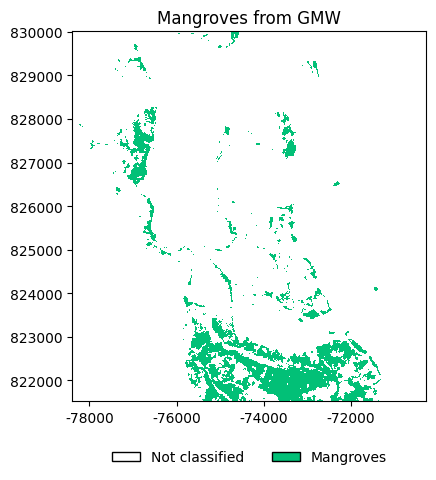

In [8]:
from myfunctions import plot_areas
from colourschemes import mangrove_colours, mangrove_labels
#from myfunctions import plot_areas
plot_areas(
    gmw_2020,          # Your dataset
    mangrove_colours,           # Color scheme
    mangrove_labels,            # Labels for the color scheme
    title="Mangroves from GMW",  # Optional custom title
    output_file="../figures/vegetated_mangrove.png"  # Optional output file path
)

### Load Intertidal Saltmarsh Extents (Worthington et al., 2023)


In [9]:
Tidal_Marsh = dc.load(
    product = 'global_tidal_marshes_2020',
    **query
)
Tidal_Marsh

<xarray.Dataset>
Dimensions:  ()
Data variables:
    *empty*

In [10]:
Tidal_Marsh_2020 = Tidal_Marsh

In [11]:
# Open Worthingtons's tidal wetland probability (2017-2019) file as xarray
saltmarsh_worthington_2020 = '/home/jovyan/data/tidal_marsh_80E_0N_v2_6.tif'
saltmarsh_2020 = rio_slurp_xarray(saltmarsh_worthington_2020, gbox=gmw_2020.geobox)

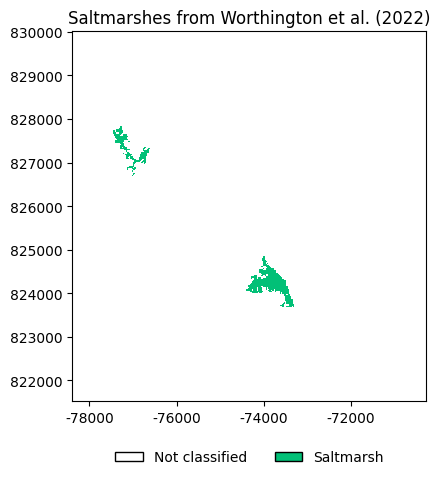

In [12]:
from colourschemes import saltmarsh_colours, saltmarsh_labels
plot_areas(
    saltmarsh_2020,          # Your dataset
    saltmarsh_colours,           # Color scheme
    saltmarsh_labels,            # Labels for the color scheme
    title="Saltmarshes from Worthington et al. (2022)",  # Optional custom title
    output_file="../figures/vegetated_saltmarsh.png"  # Optional output file path
)

### Load Cultivated Area Datasets
The cultivated area currently is determined from the World Cover map for Sri Lanka, noting that other datasets or algorithms can be ingested as a replacement. 

In [13]:
cultivated_2020 = ESA_WorldCover.classification == 40

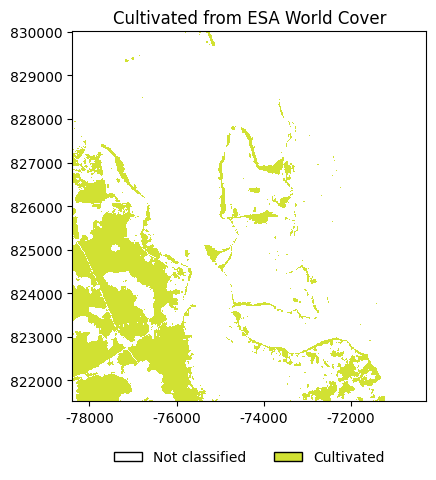

In [14]:
from colourschemes import cultivated_colours, cultivated_labels
plot_areas(
    cultivated_2020,          # Your dataset
    cultivated_colours,           # Color scheme
    cultivated_labels,            # Labels for the color scheme
    title="Cultivated from ESA World Cover",  # Optional custom title
    output_file="../figures/vegetated_cultivated.png"  # Optional output file path
)

### Load Fractional cover datasets
The fractional cover data are used to establish the extent of vegetation that is outside of the area already mapped as mangrove by the GMW.  


In [15]:
# Load Fractional Cover

# Need to add any tranformations for the VP you're using
# Get location of transformation
transformation = "fractional_cover"
trans_loc = importlib.import_module(transformation)
trans_class = transformation.split('.')[-1]

DEFAULT_RESOLVER.register('transform', trans_class, getattr(trans_loc, trans_class) )

In [16]:
product = catalog['fractional_cover']
fractional_cover = product.load(dc, **query)
fractional_cover = masking.mask_invalid_data(fractional_cover)

In [17]:
# Load WOfS

# Need to add any tranformations for the VP you're using
# Get location of transformation
transformation = "WOfS"
trans_loc = importlib.import_module(transformation)
trans_class = transformation.split('.')[-1]

DEFAULT_RESOLVER.register('transform', trans_class, getattr(trans_loc, trans_class) )

In [ ]:
product = catalog['WOfS']
wofs = product.load(dc, **query)
wofs = masking.mask_invalid_data(wofs)

wofs_mask = wofs["frequency"] >= 0.2

In [ ]:
# Create binary layer representing vegetated (1) and non-vegetated (0)
#vegetat = ((fractional_cover["PV_PC_90"] >= 50) | ((fractional_cover["NPV_PC_90"] >= 50) & (fractional_cover["NPV_PC_90"] <= 80)))
vegetat = ((fractional_cover["PV_PC_90"] >= 30) | ((fractional_cover["NPV_PC_90"] >= 30) & (fractional_cover["NPV_PC_90"] <= 80)))

# mask out water here
vegetat = vegetat.where(wofs_mask == 0, 0, 1)

# Convert to Dataset and add name
vegetat_veg_cat_ds = vegetat.to_dataset(name="vegetat_veg_cat")#.squeeze().drop('time')

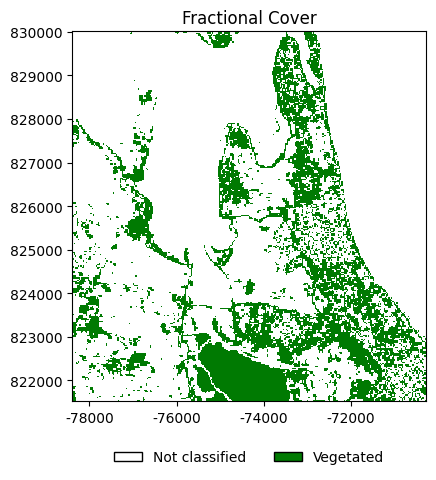

In [ ]:
from colourschemes import vegetated_colours, vegetated_labels
#def plot_areas(input, colours, labels, title, output_file):
plot_areas(vegetat_veg_cat_ds.vegetat_veg_cat,vegetated_colours, vegetated_labels, title="Fractional Cover", output_file="../figures/fractional_output.png")

## Create binary mask of vegetated/not-vegetated

**Methods:** Three approaches can be implemented to identify vegetated landscapes and separate those that are non-vegetated.  

**A. Collation of all vegetation masks:** Collation of areas of vegetation are defined with reference to the extents of a) mangrove from the Global Mangrove Watch (GMW), b) tidal saltmarsh defined by Worthington et al. (2020) OR the tidal marsh probability layer of Murray et al. (2018) and c) vegetation mapped from fractional cover data.

**B. GMW and fractional cover:** a) The GMW mangrove extent is used first, followed by b) fractional cover. The saltmarsh extent layer (Worthington et al., 2023) OR tidal probability layer of Murray et al. (2018) are used to differentiate terrestrial from aquatic vegetation but in Level 2 of the FAO LCCS. 

**C. Fractional cover only:** Areas of vegetation are defined using the fractional cover layer only, noting that this can result in exclusion of some mangroves and/or saltmarshes. 


### Method A
Combine the binary maps of mangroves (GMW), saltmarsh (Worthington et al., 2023) and other vegetation (retrieved from the Landsat archive within EASI-ASIA).

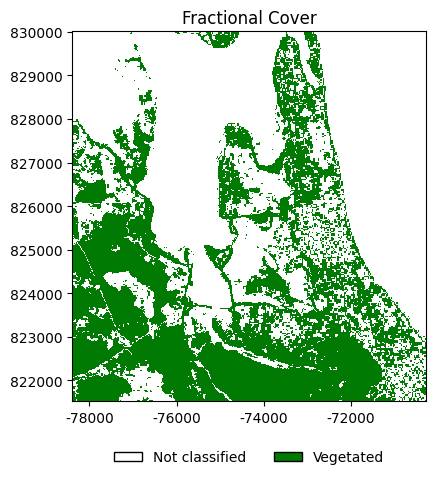

In [21]:
# Create binary layer representing vegetated (1) and non-vegetated (0)

# For coastal landscapes use the following
vegetat_veg_cat = (gmw_2020 | saltmarsh_2020 | vegetat | cultivated_2020)

# Convert to Dataset and add name
vegetat_veg_cat_ds = vegetat_veg_cat.to_dataset(name="vegetat_veg_cat").squeeze().drop('time')     

from colourschemes import vegetated_colours, vegetated_labels
#def plot_areas(input, colours, labels, title, output_file):
plot_areas(vegetat_veg_cat_ds.vegetat_veg_cat,vegetated_colours, vegetated_labels, title="Fractional Cover", output_file="../figures/vegetated_output.png")

### Method B: 
GMW and fractional cover:** a) The GMW mangrove extent is used followed by b) fractional cover. The tidal probability layer of Murray et al. (2018) is used to differentiate terrestrial from aquatic vegetation in Level 2 of the FAO LCCS. 

In [ ]:
# Create binary layer representing vegetated (1) and non-vegetated (0)

# For coastal landscapes use the following
#vegetat_veg_cat = (gmw_2020 | vegetat)

# Convert to Dataset and add name
#vegetat_veg_cat_ds = vegetat_veg_cat.to_dataset(name="vegetat_veg_cat").squeeze().drop('time') 

# Plot output
# from colourschemes import vegetated_colours, vegetated_labels
# from myfunctions import plot_areas
# #def plot_areas(input, colours, labels, title, output_file):
# plot_areas(vegetat_veg_cat_ds.vegetat_veg_cat,vegetated_colours, vegetated_labels, title="Fractional Cover", output_file="../figures/vegetated_output.png")

### Method C: 
**C. Fractional cover only:** Areas of vegetation are defined using the fractional cover layer only, noting that this can result in exclusion of some mangroves and/or saltmarshes. 

In [ ]:
# Create binary layer representing vegetated (1) and non-vegetated (0)

# For coastal landscapes use the following
#vegetat_veg_cat = vegetat

# Convert to Dataset and add name
#vegetat_veg_cat_ds = vegetat_veg_cat.to_dataset(name="vegetat_veg_cat")

# Plot output
# from colourschemes import vegetated_colours, vegetated_labels
# from myfunctions import plot_areas
# #def plot_areas(input, colours, labels, title, output_file):
# plot_areas(vegetat_veg_cat_ds.vegetat_veg_cat,vegetated_colours, vegetated_labels, title="Fractional Cover", output_file="../figures/vegetated_output.png")

### 2. Aquatic / Terrestrial

   * **Primarily Vegetated, Terrestrial**: The vegetation is influenced by the edaphic substratum
   * **Primarily Non-Vegetated, Terrestrial**: The cover is influenced by the edaphic substratum
   * **Primarily Vegetated, Aquatic or regularly flooded**: The environment is significantly influenced by the presence of water over extensive periods of time. The water is the dominant factor determining natural soil development and the type of plant communities living on its surface
   * **Primarily Non-Vegetated, Aquatic or regularly flooded**: Permanent or regularly flood aquatic areas
   

Water Observations from Space (WOfS) is used to distinguish aquatic and terrestrial areas.
https://www.sciencedirect.com/science/article/pii/S0034425715301929?via%3Dihub
<br> A threshold of 20% is applied for the annual summary dataset to remove flood events not indicative of the landscape.
<br>The Mangrove layer are also used for relevant coastal landscapes.


### Method A
Aquatic covers are associated with inundated or tidal vegetation, with the latter including a) mangrove (GMW) and b) saltmarsh (Worthington et al., 2023), and c) open water, with this determined using the WOfS dataset.

In [22]:
# Create binary layer representing aquatic (1) and not aquatic (0)

# For coastal landscapes use the following
aquatic_wat = (gmw_2020 | saltmarsh_2020 | wofs_mask)
#aquatic_wat = (gmw_2020 | saltmarsh_2020)
aquatic_wat = (aquatic_wat.where(aquatic_wat > 0) * 0 + 1).fillna(0)

# Convert to Dataset and add name
aquatic_wat_cat_ds = aquatic_wat.to_dataset(name="aquatic_wat_cat").squeeze().drop('time')  

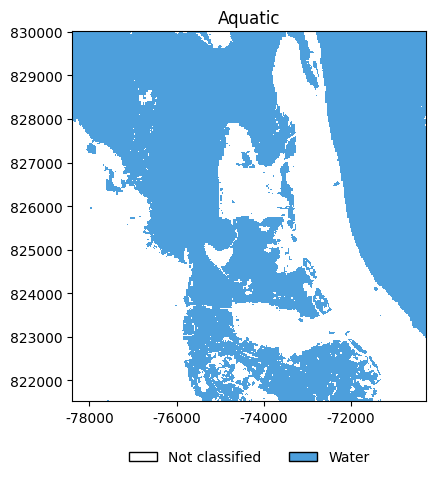

In [23]:
from colourschemes import water_colours, water_labels
#def plot_areas(input, colours, labels, title, output_file):
plot_areas(aquatic_wat_cat_ds.aquatic_wat_cat,water_colours, water_labels, title="Aquatic", output_file="../figures/aquatic_output.png")

### Method B
Aquatic covers are associated with inundated or tidal vegetation, with the latter including a) mangrove (GMW) and b) areas mapped as vegetated based on the fractional cover datasets that overlap with the tidal probablity layer of Murray et al. (2022).  

In [ ]:
# Open Murray's tidal wetland probability (2017-2019) file as xarray
#TIDAL_WETLAND_S3 = '/home/jovyan/data/Tidal_wetland_Murray_20172019_30m_PNG.tif'
#tidal_wetland = rio_slurp_xarray(TIDAL_WETLAND_S3, gbox=vegetat_veg_cat_ds.geobox)

# Threshold probability layer to 50%
#tidal_wetland_extent = ((tidal_wetland.where(tidal_wetland > 50)) * 0 + 1).fillna(0)

# Remove mudflats from Murray's layer
#tidal_wetland_veg = vegetat_veg_cat_ds.vegetat_veg_cat * tidal_wetland_extent

# Create binary layer representing aquatic (1) and terrestrial (0)
# For coastal landscapes use the following
#aquatic_wat = wofs_mask + mangrove_2020 + tidal_wetland_veg
#aquatic_wat = (aquatic_wat.where(aquatic_wat > 0) * 0 + 1).fillna(0)

# Convert to dataset and add name
#aquatic_wat_cat_ds = aquatic_wat.to_dataset(name="aquatic_wat_cat")  # .squeeze().drop('time')

### 3. Natural Vegetation / Crop or Managed Vegetation

   * **Primarily Vegetated, Terrestrial, Artificial/Managed**: Cultivated and Managed Terrestrial Areas
   * **Primarily Vegetated, Terrestrial, (Semi-)natural**: Natural and Semi-Natural Vegetation
   * **Primarily Vegetated, Aquatic or Regularly Flooded, Artificial/Managed**: Cultivated Aquatic or Regularly Flooded Areas
   * **Primarily Vegetated, Aquatic or Regularly Flooded, (Semi-)natural**: Natural and Semi-Natural Aquatic or Regularly Flooded Vegetation


### Cultivated area from ESA World Cover

In [25]:
#cultivated_2020 = ESA_WorldCover.classification == 40

In [26]:
# Create binary layer representing vegetated (1) and non-vegetated (0)

# For coastal landscapes use the following
cultman_agr_cat = cultivated_2020

# Convert to Dataset and add name
cultman_agr_cat_ds = cultman_agr_cat.to_dataset(name="cultman_agr_cat").squeeze().drop('time')     

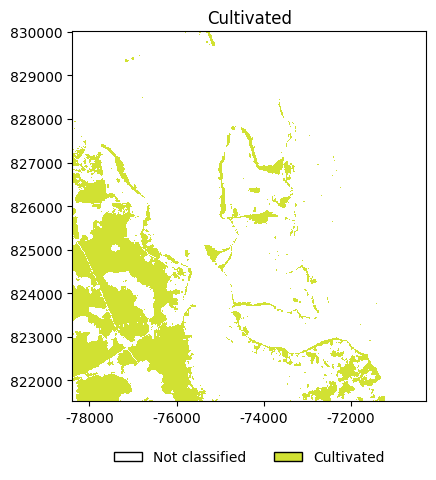

In [27]:
from colourschemes import cultivated_colours, cultivated_labels
#def plot_areas(input, colours, labels, title, output_file):
plot_areas(cultman_agr_cat_ds.cultman_agr_cat, cultivated_colours, cultivated_labels, title="Cultivated", output_file="../figures/cultivated_output.png")

In [ ]:
# Need to add any tranformations for the VP you're using
# Get location of transformation
#transformation = "geomedian"
#trans_loc = importlib.import_module(transformation)
#trans_class = transformation.split('.')[-1]

#DEFAULT_RESOLVER.register('transform', trans_class, getattr(trans_loc, trans_class) )

# load geomedian
#product = catalog['geomedian']
#geomedian = product.load(dc, **query)

# Create binary layer representing cultivated (1) and natural (0)

# calculate NDVI (PLACEHOLDER)
#NDVI = (geomedian.nbart_nir-geomedian.nbart_red)/(geomedian.nbart_nir+geomedian.nbart_red)
#cultman = (NDVI >= 0.4) & (NDVI <= 0.7)

# Convert to Dataset and add name
#cultman_agr_cat_ds = cultman.to_dataset(name="cultman_agr_cat")#.squeeze().drop('time')

# Plot output
#cultman_agr_cat_ds["cultman_agr_cat"].plot.imshow(figsize=(6, 5))

In [ ]:
# load geomedian
#product = catalog['geomedian']
#geomedian = product.load(dc, **query)

In [ ]:
# Create binary layer representing cultivated (1) and natural (0)

# calculate NDVI (PLACEHOLDER)
#NDVI = (geomedian.nbart_nir-geomedian.nbart_red)/(geomedian.nbart_nir+geomedian.nbart_red)
#cultman = (NDVI >= 0.4) & (NDVI <= 0.7)

# Convert to Dataset and add name
#cultman_agr_cat_ds = cultman.to_dataset(name="cultman_agr_cat")#.squeeze().drop('time')

In [ ]:
# Plot output
#cultman_agr_cat_ds["cultman_agr_cat"].plot.imshow(figsize=(6, 5))

### 4. Natural Surfaces / Artificial Surfaces

In [28]:
artificial_2020 = ESA_WorldCover.classification == 50

In [29]:
# Create binary layer representing vegetated (1) and non-vegetated (0)

# For coastal landscapes use the following
artific_urb_cat = artificial_2020

# Convert to Dataset and add name
artific_urb_cat_ds = artific_urb_cat.to_dataset(name="artific_urb_cat").squeeze().drop('time')     

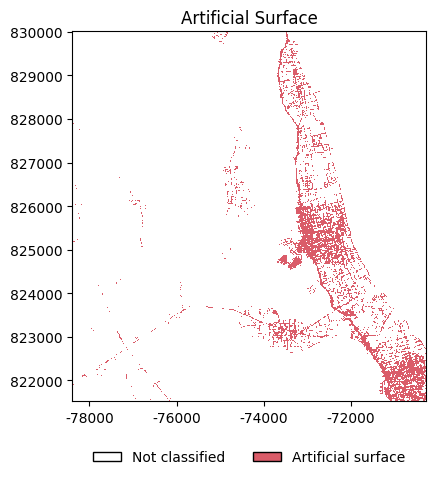

In [30]:
from colourschemes import artsurf_colours, artsurf_labels
#def plot_areas(input, colours, labels, title, output_file):
plot_areas(artific_urb_cat_ds.artific_urb_cat, artsurf_colours, artsurf_labels, title="Artificial Surface", output_file="../figures/artsurf_output.png")

In [ ]:
# # load in OSM vector data just for AOI extent
# OSM_blds = gpd.read_file('/home/jovyan/livingearth_png/data/srilanka/srilanka_osm.gpkg', layer="gis_osm_buildings_a_free_1")
# #OSM_blds = gpd.read_file(OSM_S3, layer="buildings", bbox=bbox)
# #OSM_airports = gpd.read_file(OSM_S3, layer="aeroway_ln", bbox=bbox)
# #OSM_roads = gpd.read_file(OSM_S3, layer="highway_ln", bbox=bbox)

# # get bbox to get geom of gdf
# #xmin, ymin, xmax, ymax = bbox

# # Check if the vector dataset is empty
# if OSM_blds.empty:
#     # If the vector dataset is empty, create a raster of zeros matching the shape of the geomedians
#     OSM_blds_xr = xr.DataArray(
#         np.zeros_like(wofs_mask),
#         coords=wofs_mask.coords,
#         dims=wofs_mask.dims,
#         attrs=wofs_mask.attrs,
#     )
# else:
#     OSM_blds_AOI = OSM_blds.cx[xmin:xmax, ymin:ymax]
#     OSM_blds_xr = xr_rasterize(gdf=OSM_blds_AOI, da=wofs_mask)

# # Check if the vector dataset is empty
# if OSM_airports.empty:
#     # If the vector dataset is empty, create a raster of zeros matching the shape of the geomedians
#     OSM_airports_xr = xr.DataArray(
#         np.zeros_like(wofs_mask),
#         coords=wofs_mask.coords,
#         dims=wofs_mask.dims,
#         attrs=wofs_mask.attrs,
#     )
# else:
#     OSM_airports_AOI = OSM_airports.cx[xmin:xmax, ymin:ymax]
#     OSM_airports_xr = xr_rasterize(gdf=OSM_airports_AOI, da=wofs_mask)

#     # Check if the vector dataset is empty
# if OSM_roads.empty:
#     # If the vector dataset is empty, create a raster of zeros matching the shape of the geomedians
#     OSM_roads_xr = xr.DataArray(
#         np.zeros_like(wofs_mask),
#         coords=wofs_mask.coords,
#         dims=wofs_mask.dims,
#         attrs=wofs_mask.attrs,
#     )
# else:
#     # only selecting out roads that are sealed and fit the taxonomy of artificial surfaces
#     OSM_roads_filtered = OSM_roads[
#         OSM_roads["highway"].isin(
#             [
#                 "primary",
#                 "primary_link",
#                 "secondary",
#                 "secondary_link",
#                 "trunk",
#                 "trunk_link",
#             ]
#         )
#     ]
#     OSM_roads_AOI = OSM_roads.cx[xmin:xmax, ymin:ymax]
#     OSM_roads_xr = xr_rasterize(gdf=OSM_roads_AOI, da=wofs_mask)

# # combine OSM xarrays
# OSM_xr = xr.where(
#     (OSM_blds_xr == 1) | (OSM_airports_xr == 1) | (OSM_roads_xr == 1), 1, 0
# )

# # Convert to Dataset and add name
# artific_urb_cat_ds = OSM_xr.to_dataset(name="artific_urb_cat")


### **Collect environmental variables into array for passing to classification system**

In [31]:
variables_xarray_list = []
variables_xarray_list.append(vegetat_veg_cat_ds)
variables_xarray_list.append(aquatic_wat_cat_ds)
variables_xarray_list.append(cultman_agr_cat_ds)
variables_xarray_list.append(artific_urb_cat_ds)
# variables_xarray_list.append(artwatr_wat_cat_ds)

## <font color=blue>Classification</font>

**The LCCS classificaition is hierachial. The 8 classes are shown below**

| Class name | Code | Numeric code |
|----------------------------------|-----|-----|
| Cultivated Terrestrial Vegetated | A11 | 111 |
| Natural Terrestrial Vegetated | A12 | 112 |
| Cultivated Aquatic Vegetated | A23 | 123 |
| Natural Aquatic Vegetated | A24 | 124 |
| Artificial Surface | B15 | 215 |
| Natural Surface | B16 | 216 |
| Artificial Water | B27 | 227 |
| Natural Water | B28 | 228 |


In [32]:
# Merge to a single dataframe
classification_data = xr.merge(variables_xarray_list)

In [33]:
# Apply Level 3 classification using separate function. Works through in three stages
level1, level2, level3 = lccs_l3.classify_lccs_level3(classification_data)

In [34]:
# Save classification values back to xarray
out_class_xarray = xr.Dataset(
    {"level1" : (classification_data["vegetat_veg_cat"].dims, level1),
     "level2" : (classification_data["vegetat_veg_cat"].dims, level2),
     "level3" : (classification_data["vegetat_veg_cat"].dims, level3)})
classification_data = xr.merge([classification_data, out_class_xarray])

## <font color=blue>Results</font>

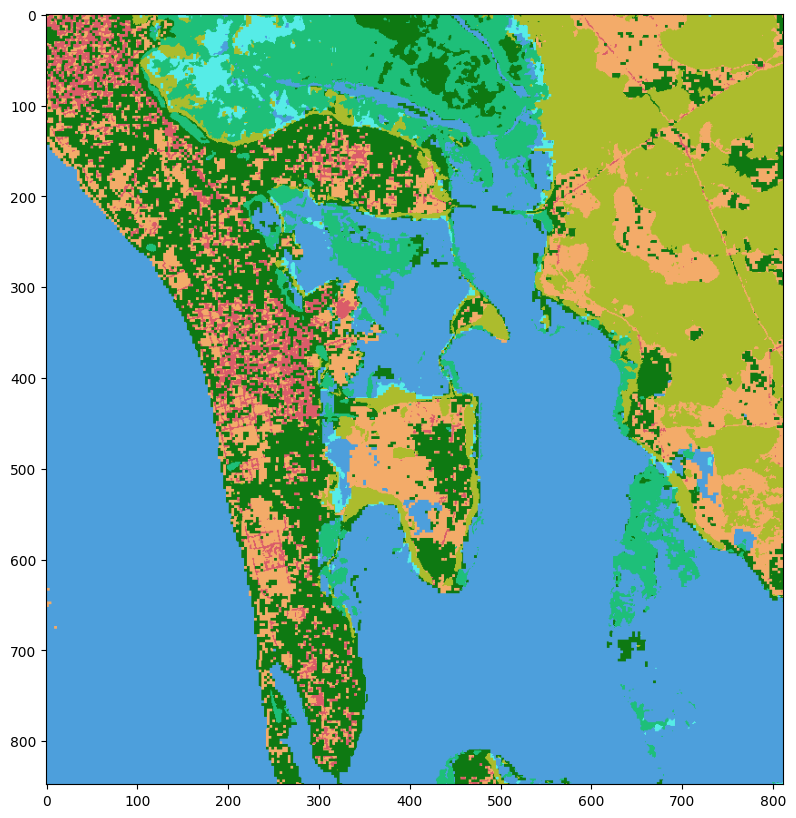

In [35]:
red, green, blue, alpha = lccs_l3.colour_lccs_level3(level3)
img = np.dstack([red, green, blue, alpha])

# Rotate the image by 180 degrees - SHOULDN'T HAVE TO DO THIS BUT WAS NOT DISPLAYING PROPERLY
img = np.rot90(img, 4)

# Display the rotated image
plt.figure(figsize=(12, 10))
plt.imshow(img)
plt.show()


### **Save results to geotiff**

In [37]:
min_x = classification_data.coords['x'].min().values
max_x = classification_data.coords['x'].max().values
min_y = classification_data.coords['y'].min().values
max_y = classification_data.coords['y'].max().values

res_x = 30 
res_y = -30 
crs = 'EPSG:32755'
# Write out
output_rgb_file_name = "../data/level3_test.tif"
out_file_transform = [res_x, 0, min_x, 0, res_y, max_y]
output_x_size = int((max_x - min_x)/res_x)
output_y_size = int((min_y - max_y)/res_y)

# Write RGB colour scheme out
rgb_dataset = rasterio.open(output_rgb_file_name, 'w', driver='GTiff',
                            height=output_y_size, width=output_x_size,
                            count=3, dtype=level3.dtype,
                            crs=crs, transform=out_file_transform)
rgb_dataset.write(red, 1)
rgb_dataset.write(green, 2)
rgb_dataset.write(blue, 3)
rgb_dataset.close()